<div style="background-color:#e8f4f8; padding:15px; border-radius:8px;">
<h2 style="color:#2980b9; margin-top:0;">🔄 Machine Learning LifeCycle</h2>
<ul style="font-size: 16px; color: #2c3e50;">
<li><b>1) Data Collection or Data Reading</b></li>
<li><b>2) EDA (Exploratory Data Analysis)</b></li>
<li><b>3) Cleaning, Preprocessing, Feature Engineering and Selection</b></li>
<li><b>4) Model Selection</b></li>
<li><b>5) Model Training</b></li>
<li><b>6) Model Evaluation and Tuning</b></li>
<li><b>7) Model Deployment</b></li>
<li><b>8) Model Monitoring & Maintainance</b></li>
</ul>
</div>

In [1]:
# Import all the necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import missingno as msno
import math
import pandas as pd
from scipy.stats import pointbiserialr
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# Read the data files 
sentiment_df = pd.read_csv(r'E:\Dinuk\Jobs\Tasks\newnop\sentiment-analysis\dataset\IMDB Dataset.csv')

In [3]:
df = sentiment_df.copy()    

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
# null count of each column 
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
# check duplicate rows
df.duplicated().sum()

418

In [9]:
# Check different data types of the columns in the training set
df.dtypes

review       object
sentiment    object
dtype: object

In [10]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

C:\Users\LOQ\AppData\Local\Temp\ipykernel_47576\955836946.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment",data=df,palette="rainbow")


<Axes: xlabel='sentiment', ylabel='count'>

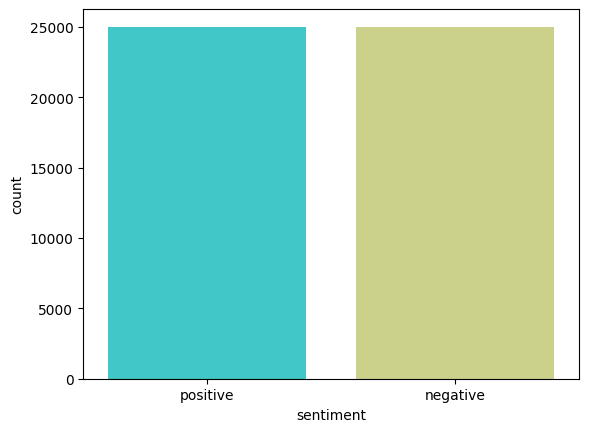

In [11]:
sns.countplot(x="sentiment",data=df,palette="rainbow")

In [12]:
import nltk
nltk.download('punkt')
df['num_of_characters'] = df['review'].apply(len)
df['num_words']=df['review'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentences']=df['review'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,review,sentiment,num_of_characters,num_words,num_sentences
0,One of the other reviewers has mentioned that ...,positive,1761,380,10
1,A wonderful little production. <br /><br />The...,positive,998,201,7
2,I thought this was a wonderful way to spend ti...,positive,926,205,4
3,Basically there's a family where a little boy ...,negative,748,175,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,283,9


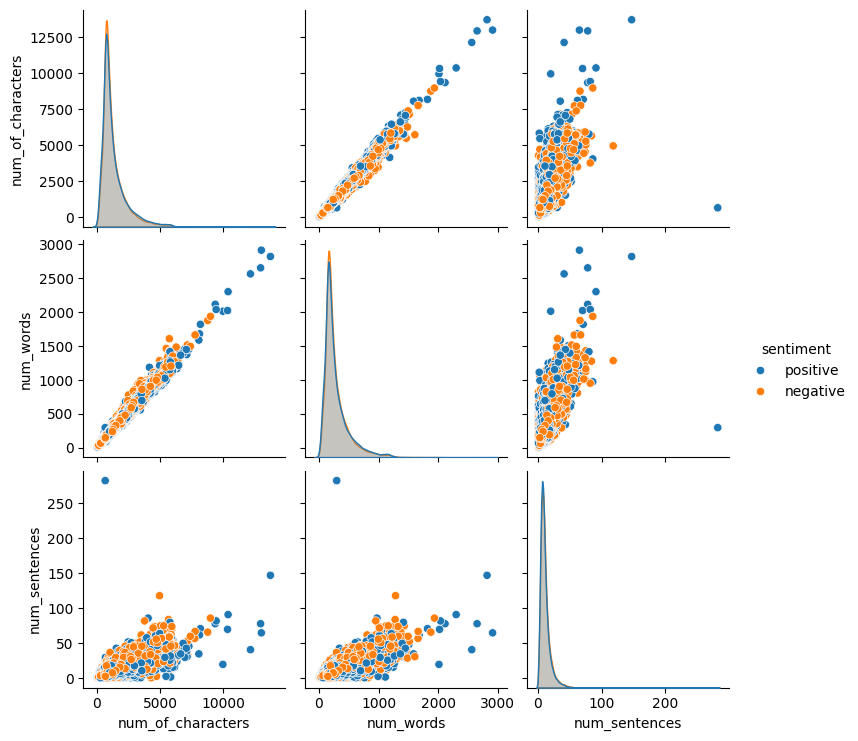

In [13]:
sns.pairplot(df,hue='sentiment')

## Data Preprocessing


### Data Cleaning

In [14]:
# Check if the null value exists
df["sentiment"].isnull().sum()

0

In [15]:
## In our data set there is no null values. But if there are null values we can replace null values with null string
df = df.where((pd.notnull(df)),'')

In [16]:
duplicates_data = df[df.duplicated()]
duplicates_data


,review,sentiment,num_of_characters,num_words,num_sentences
3537,Quite what the producers of this appalling ada...,negative,2308,473,21
3769,My favourite police series of all time turns t...,positive,488,106,10
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive,696,132,7
6352,If you liked the Grinch movie... go watch that...,negative,548,114,5
6479,I want very much to believe that the above quo...,negative,2750,543,14
...,...,...,...,...,...
49912,This is an incredible piece of drama and power...,positive,918,178,6
49950,This was a very brief episode that appeared in...,negative,1075,220,9
49984,Hello it is I Derrick Cannon and I welcome you...,negative,2232,480,14
49986,This movie is a disgrace to the Major League F...,negative,641,136,7


In [17]:
unique_chars = set(''.join(df['review']))
print(unique_chars)


{',', 'Q', 'À', '/', '«', '″', 'ל', 'y', 'k', 'Ø', 'o', '}', 'P', '¾', 'Þ', 'e', 'V', '@', '_', '₤', '\x8d', '¤', 'Ç', 'Z', '8', 'ý', '、', 'ô', 'q', '$', 'O', 'b', '|', 'ן', '6', 'm', 'u', 'X', 'Ż', 'ō', 'B', 'K', '\t', '4', 'r', '2', 'Å', 'i', 'ì', '\x9e', '<', '~', 'א', 'û', '"', 'ı', '5', ';', '¦', 'Ï', 'º', 'A', 'æ', 'Á', '\x8e', 'j', 'ג', 'Ó', 'ê', 'C', '.', 'G', 'å', '1', '\x95', 'd', 'T', '?', '#', 'ו', 'É', 'U', 'c', '0', 'ü', '\x91', 'D', 'î', '©', '‘', 'F', 'Ö', '\x85', '¿', '\x96', 'á', '{', '¡', 'ä', 'h', 'p', '9', 'é', '\x97', '·', 'W', 'ç', 'f', 'ë', '”', '=', '★', 'S', '>', '½', '\xa0', 'ğ', 'ù', '\\', '-', '3', '°', 'J', 'g', '(', '®', '…', 'è', '[', 'z', 'ú', '*', 'à', 'L', 'כ', ')', '»', 'Æ', '\x08', 'ª', 'E', '³', 'ר', 'ò', '▼', '\x84', 'ß', '–', 'Ä', '7', 'Ã', '+', 'M', 'a', "'", 'ö', 'v', 'l', ' ', '\uf0b7', 'ã', '§', 'Ð', '%', 'x', 'R', '¨', '´', 'I', '\x80', 'ð', '!', '“', 'N', 'H', ']', 'ï', 't', 'ó', 'õ', '^', '\x9a', '\xad', '¢', '\x10', 'Ü', 'n', 'Y', 'È', 'Â

In [18]:
print(len(unique_chars))

206


In [19]:
## Remove all duplucates , keeping first occurrence of the duplicates
df_new = df.drop_duplicates(keep='first')
df_new = df_new.drop(['num_of_characters','num_words','num_sentences'],axis=1)
df_new.shape

(49582, 2)

In [20]:
df_new.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [21]:
import string
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (run once per environment)
nltk.download('punkt', quiet=True) 
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Initialize global objects once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    # Handle potential None/NaN values before processing
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML tags using BeautifulSoup
    # 'lxml' is the parser used; get_text() extracts only the human-readable content
    text = BeautifulSoup(text, "lxml").get_text()

    # 2. Lowercase the text
    text = text.lower()
    
    # 3. Remove punctuation and special characters
    text = ''.join([char for char in text if char.isalnum() or char.isspace()])

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # 6. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Rejoin tokens into a single string
    return ' '.join(tokens)


In [22]:
df_new['transformed_text']=df_new['review'].apply(preprocessing)
df_new.replace({'sentiment':{'negative':0,'positive':1}},inplace=True)
df_new.head()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_47576\3812469259.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new.replace({'sentiment':{'negative':0,'positive':1}},inplace=True)


,review,sentiment,transformed_text
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching 1 oz episode y...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [23]:
#Vocabulary
from collections import Counter
vocab = Counter()
for sentence in df_new['transformed_text']:
    vocab.update(sentence.split())

In [24]:
len(vocab)
df_new.shape

(49582, 3)

In [25]:
tokens = [key for key in vocab if vocab[key] >= 10]

In [ ]:
len(tokens)

In [ ]:
#Dictonary save code 
def save_vocabulary(lines,filename):
    data='\n'.join(lines)
    file=open(filename,'w',encoding='utf-8')
    file.write(data)
    file.close()
save_vocabulary(tokens,'../static/vocabulary.txt')

In [ ]:
#install pip install wordcloud
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')


In [ ]:
spam_wc = wc.generate(data_new[data_new['Category']==0]['transformed_text'].str.cat(sep=" "))

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [ ]:
ham_wc = wc.generate(data_new[data_new['Category']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
from sklearn.model_selection import train_test_split
x=data_new['transformed_text']
y=data_new['Category']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
#Vectorization
def Vectorizer(ds,vocabulary):
    vectorized_list=[]
    for sentence in ds:
        sentence_list = np.zeros(len(vocabulary))
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i] = 1
        vectorized_list.append(sentence_list)
    vectorized_list_new = np.asarray(vectorized_list,dtype='float32')
    return vectorized_list_new

In [ ]:
vectorized_x_train = Vectorizer(x_train,tokens)

In [ ]:
vectorized_x_test = Vectorizer(x_test,tokens)

In [ ]:
from imblearn.over_sampling import SMOTE

res=SMOTE(random_state=50)
x_train_res,y_train_res=res.fit_resample(vectorized_x_train,y_train)

In [ ]:
plt.pie(y_train_res.value_counts(),labels=['ham','spam'])


In [ ]:
print(x_train_res)

In [ ]:
from sklearn.linear_model import LogisticRegression
model_LR=LogisticRegression()
model_LR.fit(x_train_res,y_train_res)


In [ ]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score,confusion_matrix


In [ ]:
prediction_on_training_LR=model_LR.predict(x_train_res)

accuracy_on_training_LR=accuracy_score(y_train_res,prediction_on_training_LR)
precision_score_on_training_LR=precision_score(y_train_res,prediction_on_training_LR)
recall_score_on_training_LR=recall_score(y_train_res,prediction_on_training_LR)
f1_score_on_training_LR=f1_score(y_train_res,prediction_on_training_LR)
print("Accuracy on training data:",accuracy_on_training_LR,"\nPrecision on training data:",precision_score_on_training_LR,"\nRecall on training data:",recall_score_on_training_LR,"\nF1 Score on training data:",f1_score_on_training_LR)

In [ ]:
prediction_on_testing_LR=model_LR.predict(vectorized_x_test)

accuracy_on_testing_LR=accuracy_score(y_test,prediction_on_testing_LR)
precision_score_LR=precision_score(y_test,prediction_on_testing_LR)
recall_score_LR=recall_score(y_test,prediction_on_testing_LR)
f1_score_LR=f1_score(y_test,prediction_on_testing_LR)
print("Accuracy on Testing: ",accuracy_on_testing_LR,"\nPrecision on Testing: ",precision_score_LR,"\nRecall on Testing: ",recall_score_LR,"\nF1 Score on Testing: ",f1_score_LR)

In [ ]:
confusion_matrix_LR=confusion_matrix(y_test,prediction_on_testing_LR)
confusion_matrix_LR

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
class_prior = [0.3,0.7]
param_grid_NB={'alpha':[0.00000001,0.0000001, 0.000001,0.00001,0.0001,0.001,0.01,0.1,1,2,3,4,5,6,7,8,9,10,15,20,25,30,40,50],
            'force_alpha':[True,False],
            'fit_prior':[True,False],
            'class_prior':[class_prior,'None']}

In [ ]:
grid_search_NB =GridSearchCV(estimator=model_NB,param_grid=param_grid_NB)
grid_search_NB.fit(x_train_res,y_train_res)

In [ ]:
grid_search_NB.best_params_

In [ ]:
grid_search_NB.score(vectorized_x_test,y_test)

In [ ]:
param_grid_LR={'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2'],  # Regularization type ('l1' or 'l2')
    'solver': ['liblinear'],  # Solver algorithm, suitable for small datasets
    'multi_class': ['auto', 'ovr'],}

In [ ]:
grid_search_LR =GridSearchCV(estimator=model_LR,param_grid=param_grid_LR)
grid_search_LR.fit(x_train_res,y_train_res)

In [ ]:
grid_search_LR.best_params_

In [ ]:
grid_search_LR.score(vectorized_x_test,y_test)

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
x = Vectorizer(data_new['transformed_text'],tokens)
cross_val_score_LR=cross_val_score(model_LR,x,y,cv=10).mean()
cross_val_score_LR

In [ ]:
cross_val_score_NB=cross_val_score(model_NB,x,y,cv=10).mean()
cross_val_score_NB

In [ ]:
import pickle 
with open('../static/logistic_model.pickle','wb') as file:
    pickle.dump(model_LR,file)

with open('../static/naivebayes_model.pickle','wb') as file:
    pickle.dump(model_NB,file)

In [ ]:
#Vectorization
def Vectorizer(ds,vocabulary):
    vectorized_list=[]
    for sentence in ds:
        sentence_list = np.zeros(len(vocabulary))
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i] = 1
        vectorized_list.append(sentence_list)
    vectorized_list_new = np.asarray(vectorized_list,dtype='float32')
    return vectorized_list_new

In [ ]:
vectorized_input = Vectorizer([preprocessed_input],tokens)

In [ ]:
import pickle
with open('../static/logistic_model.pickle','rb') as file:
    logistic_model = pickle.load(file)

In [ ]:
def get_prediction_from_LR(vectorized_input):
    prediction = logistic_model.predict(vectorized_input)
    if(prediction[0]==1):
        return 'Not Spam'
    else:
        return 'Spam'

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import logging

# Download necessary NLTK datasets
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class IMDBSentimentAnalyzer:
    """
    A professional-grade sentiment analysis pipeline for the IMDB dataset using Deep Learning.
    """
    
    def __init__(self, max_features=20000, max_len=200, embedding_dim=128):
        self.max_features = max_features
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.model = None
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def load_data(self, filepath):
        """Loads the dataset from a CSV file."""
        logger.info(f"Loading data from {filepath}...")
        try:
            df = pd.read_csv(filepath)
            logger.info(f"Dataset loaded successfully with shape {df.shape}")
            return df
        except Exception as e:
            logger.error(f"Failed to load dataset: {e}")
            raise

    def clean_text(self, text):
        """
        Comprehensive text cleaning:
        1. Remove HTML tags
        2. Remove non-alphabetic characters
        3. Convert to lowercase
        4. Remove stopwords
        5. Lemmatization
        """
        # Remove HTML
        text = BeautifulSoup(text, "html.parser").get_text()
        
        # Remove non-letters and convert to lower case
        text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
        
        # Tokenize (simple split)
        words = text.split()
        
        # Remove stopwords and lemmatize
        cleaned_words = [
            self.lemmatizer.lemmatize(word) 
            for word in words 
            if word not in self.stop_words
        ]
        
        return " ".join(cleaned_words)

    def preprocess_data(self, df):
        """Applies text cleaning and prepares sequences for training."""
        logger.info("Starting text preprocessing...")
        
        # Clean reviews
        # Assuming columns are 'review' and 'sentiment' ('positive'/'negative')
        df['cleaned_review'] = df['review'].apply(self.clean_text)
        
        # Convert sentiment to binary (1 for positive, 0 for negative)
        df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
        
        logger.info("Tokenizing text...")
        self.tokenizer = Tokenizer(num_words=self.max_features, oov_token="<OOV>")
        self.tokenizer.fit_on_texts(df['cleaned_review'])
        
        # Convert text to sequences
        sequences = self.tokenizer.texts_to_sequences(df['cleaned_review'])
        
        # Pad sequences
        logger.info(f"Padding sequences to length {self.max_len}...")
        X = pad_sequences(sequences, maxlen=self.max_len, padding='post', truncating='post')
        y = df['label'].values
        
        return X, y

    def build_model(self):
        """Constructs a Bidirectional LSTM architecture."""
        logger.info("Building model architecture...")
        
        self.model = Sequential([
            Embedding(
                input_dim=self.max_features, 
                output_dim=self.embedding_dim, 
                input_length=self.max_len
            ),
            Bidirectional(LSTM(128, return_sequences=True)),
            Dropout(0.3),
            Bidirectional(LSTM(64)),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        self.model.summary(print_fn=logger.info)

    def train(self, X_train, y_train, X_val, y_val, batch_size=128, epochs=20):
        """Trains the model with early stopping, checkpointing, and LR reduction."""
        if self.model is None:
            raise ValueError("Model has not been built. Call build_model() first.")
            
        logger.info("Configuring callbacks...")
        
        callbacks = [
            # Stop training when validation accuracy stops improving
            EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=1
            ),
            # Save the best model
            ModelCheckpoint(
                filepath='best_sentiment_model.keras',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            ),
            # Reduce learning rate when validation loss plateaus
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ]
        
        logger.info("Starting training process...")
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            batch_size=batch_size,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )
        
        return history

    def evaluate(self, X_test, y_test):
        """Evaluates model performance on a test set."""
        logger.info("Evaluating model on test data...")
        loss, accuracy = self.model.evaluate(X_test, y_test, verbose=0)
        logger.info(f"Test Loss: {loss:.4f}")
        logger.info(f"Test Accuracy: {accuracy:.4f}")
        return loss, accuracy

    def predict_sentiment(self, text):
        """Predicts sentiment for a single unseen text."""
        if self.model is None or self.tokenizer is None:
            raise ValueError("Model or tokenizer is missing. Ensure model is trained.")
            
        cleaned = self.clean_text(text)
        seq = self.tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=self.max_len, padding='post', truncating='post')
        
        prediction = self.model.predict(padded)[0][0]
        sentiment = "Positive" if prediction >= 0.5 else "Negative"
        
        return sentiment, prediction

# ==========================================
# Execution Pipeline
# ==========================================
if __name__ == "__main__":
    # Ensure you have the dataset downloaded. 
    # Usually available on Kaggle: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
    DATASET_PATH = 'IMDB Dataset.csv' 
    
    analyzer = IMDBSentimentAnalyzer()
    
    try:
        # 1. Load Data
        df = analyzer.load_data(DATASET_PATH)
        
        # 2. Preprocess
        X, y = analyzer.preprocess_data(df)
        
        # 3. Train/Val/Test Split (80-10-10)
        X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
        X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42) # 0.1111 of 0.9 is ~0.1
        
        # 4. Build Model
        analyzer.build_model()
        
        # 5. Train Model
        history = analyzer.train(X_train, y_train, X_val, y_val)
        
        # 6. Evaluate
        analyzer.evaluate(X_test, y_test)
        
        # 7. Test custom predictions
        sample_positive = "This movie was absolutely fantastic! The acting was brilliant and the plot was engaging."
        sample_negative = "Terrible waste of time. The script was awful and the directing was amateurish."
        
        logger.info(f"Testing text: '{sample_positive}' -> Predicted: {analyzer.predict_sentiment(sample_positive)}")
        logger.info(f"Testing text: '{sample_negative}' -> Predicted: {analyzer.predict_sentiment(sample_negative)}")
        
    except FileNotFoundError:
        logger.error(f"Dataset not found at {DATASET_PATH}. Please download it and update the path.")
    except Exception as e:
        logger.error(f"An error occurred during pipeline execution: {e}")

In [ ]:
import torch
import numpy as np
import pandas as pd
import logging
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

# Configure professional logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

class BERTSentimentAnalyzer:
    """
    A production-ready pipeline for fine-tuning BERT on the IMDB sentiment dataset.
    """
    
    def __init__(self, model_name="bert-base-uncased", max_length=512):
        self.model_name = model_name
        self.max_length = max_length
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        logger.info(f"Using device: {self.device}")
        
        # Load the tokenizer
        logger.info(f"Loading tokenizer for {model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        
        # We don't load the model in __init__ to save memory until training begins
        self.model = None

    def load_and_prepare_data(self, filepath, sample_size=None):
        """
        Loads the CSV and converts it into Hugging Face Dataset objects.
        BERT requires minimal preprocessing compared to LSTMs because its 
        WordPiece tokenizer handles subwords, punctuation, and casing internally.
        """
        logger.info(f"Loading data from {filepath}...")
        df = pd.read_csv(filepath)
        
        if sample_size:
            logger.info(f"Sampling {sample_size} rows for faster testing...")
            df = df.sample(sample_size, random_state=42)
            
        # Convert sentiment string to integer labels
        df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
        
        # We only need the text and the label
        df = df[['review', 'label']]
        
        # Split: Train (80%), Val (10%), Test (10%)
        train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
        val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
        
        logger.info(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")
        
        # Convert pandas DataFrames to Hugging Face Datasets
        train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
        val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
        test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
        
        return train_dataset, val_dataset, test_dataset

    def tokenize_function(self, examples):
        """Applies the BERT tokenizer to the text column."""
        return self.tokenizer(
            examples["review"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length
        )

    def compute_metrics(self, pred):
        """Calculates evaluation metrics during training."""
        labels = pred.label_ids
        preds = pred.predictions.argmax(-1)
        
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
        acc = accuracy_score(labels, preds)
        
        return {
            'accuracy': acc,
            'f1': f1,
            'precision': precision,
            'recall': recall
        }

    def train(self, train_dataset, val_dataset, output_dir="./bert-sentiment-model", epochs=3, batch_size=8):
        """
        Fine-tunes the BERT model using the Hugging Face Trainer API.
        """
        logger.info("Tokenizing datasets...")
        tokenized_train = train_dataset.map(self.tokenize_function, batched=True)
        tokenized_val = val_dataset.map(self.tokenize_function, batched=True)
        
        # Initialize the model (2 labels for positive/negative)
        logger.info(f"Loading pre-trained model {self.model_name}...")
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2
        ).to(self.device)
        
        # Define training arguments
        training_args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=2e-5,              # Standard learning rate for fine-tuning BERT
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2, # Evaluation uses less memory
            num_train_epochs=epochs,
            weight_decay=0.01,               # L2 regularization
            evaluation_strategy="epoch",     # Evaluate at the end of every epoch
            save_strategy="epoch",           # Save checkpoint every epoch
            load_best_model_at_end=True,     # Early stopping requirement
            metric_for_best_model="f1",      # Metric to use for best model
            greater_is_better=True,
            logging_dir='./logs',
            logging_steps=100,
            fp16=torch.cuda.is_available(),  # Use mixed precision if GPU is available (faster)
            report_to="none"                 # Disable W&B/Tensorboard logging for this script
        )
        
        # Initialize Trainer
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            compute_metrics=self.compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Stop if no improvement after 2 epochs
        )
        
        logger.info("Starting training...")
        trainer.train()
        
        logger.info(f"Saving best model to {output_dir}...")
        trainer.save_model(output_dir)
        self.tokenizer.save_pretrained(output_dir)
        
        return trainer

    def evaluate(self, trainer, test_dataset):
        """Evaluates the fine-tuned model on the held-out test set."""
        logger.info("Evaluating on test dataset...")
        tokenized_test = test_dataset.map(self.tokenize_function, batched=True)
        
        results = trainer.evaluate(tokenized_test)
        logger.info(f"Test Results: {results}")
        return results

    def predict(self, texts, model_path="./bert-sentiment-model"):
        """Predicts sentiment for new, unseen texts."""
        if self.model is None:
            logger.info(f"Loading fine-tuned model from {model_path}...")
            self.model = AutoModelForSequenceClassification.from_pretrained(model_path).to(self.device)
            self.tokenizer = AutoTokenizer.from_pretrained(model_path)
            
        self.model.eval()
        
        # Tokenize inputs
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        ).to(self.device)
        
        # Perform inference
        with torch.no_grad():
            outputs = self.model(**inputs)
            
        # Get predictions
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        confidence = torch.max(probabilities, dim=-1)[0].cpu().numpy()
        
        results = []
        for text, pred, conf in zip(texts, predictions, confidence):
            sentiment = "Positive" if pred == 1 else "Negative"
            results.append({"text": text, "sentiment": sentiment, "confidence": float(conf)})
            
        return results

# ==========================================
# Execution Pipeline
# ==========================================
if __name__ == "__main__":
    DATASET_PATH = 'IMDB Dataset.csv' 
    OUTPUT_MODEL_DIR = "./final_bert_sentiment"
    
    # Using distilbert is highly recommended for faster training on consumer hardware
    # while retaining 97% of BERT's performance. Change to "bert-base-uncased" for full BERT.
    analyzer = BERTSentimentAnalyzer(model_name="distilbert-base-uncased")
    
    try:
        # 1. Load Data
        # IMPORTANT: Set sample_size=1000 for a quick test run to verify the code works. 
        # Remove sample_size or set to None to train on the full 50k dataset.
        train_ds, val_ds, test_ds = analyzer.load_and_prepare_data(DATASET_PATH, sample_size=None)
        
        # 2. Train the Model
        # Note: Batch size depends on your GPU VRAM. 8 is safe for 8GB VRAM. 
        # If you get CUDA out of memory, reduce batch_size to 4.
        trainer = analyzer.train(
            train_dataset=train_ds,
            val_dataset=val_ds,
            output_dir=OUTPUT_MODEL_DIR,
            epochs=3,
            batch_size=8 
        )
        
        # 3. Evaluate
        analyzer.evaluate(trainer, test_ds)
        
        # 4. Run Inference
        samples = [
            "This movie was an absolute masterpiece. The cinematography was breathtaking.",
            "I walked out halfway through. The dialogue felt incredibly forced and unnatural.",
            "It was okay. Not the best I've seen, but fine for a lazy Sunday afternoon."
        ]
        
        predictions = analyzer.predict(samples, model_path=OUTPUT_MODEL_DIR)
        
        print("\n--- Inference Results ---")
        for p in predictions:
            print(f"Sentiment: {p['sentiment']} (Conf: {p['confidence']:.2f}) | Text: {p['text']}")
            
    except Exception as e:
        logger.error(f"Pipeline failed: {e}")